In [51]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from src.datasets.mos2_sr import MOS2SRDataset
from src.models.our_method.swin_cafm import SwinCAFM

fp = "/playpen/mufan/levi/tianlong-chen-lab/material-super-resolution/__exps__/foundation-models/3. combined/4x/2025-03-03_10-59-32_DS={all}-[X|y]-BS=32-opt=Adam-lr=1e-5/DS={all}-[X|y]-BS=32-opt=Adam-lr=1e-5_best.pth"
dataset = MOS2SRDataset(split="val", upsample_factor=4)
model: SwinCAFM = torch.load(fp).cuda();

/tmp/ipykernel_1539868/3170313934.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model: SwinCAFM = torch.load(fp).cuda();


In [52]:
@torch.no_grad()
def normalize(X: torch.Tensor, mu: float, sigma: float) -> torch.Tensor:
    X_mean = X.mean()
    X_std = X.std()
    if X_std == 0:
        return X * 0 + mu
    return (X - X_mean) / X_std * sigma + mu

mu = dataset.current_maps_mean
sigma = dataset.current_maps_std

item = dataset[0]
y = item["y"]
y_sparse = item["y_sparse"].unsqueeze(0).cuda()

with torch.no_grad():
    y_hat = model(y_sparse)

y        = normalize(y, mu, sigma)
y_hat    = normalize(y_hat, mu, sigma)

y_hat_nearest = F.interpolate(
    y_sparse.detach().cpu(),
    scale_factor=4,
    mode='linear',
).squeeze(0).squeeze(0)

y_hat_bilinear = F.interpolate(
    y_sparse.unsqueeze(0).detach().cpu(),
    scale_factor=4,
    mode='bilinear',
).squeeze(0).squeeze(0)

y_hat_bicubic = F.interpolate(
    y_sparse.unsqueeze(0).detach().cpu(),
    scale_factor=4,
    mode='bilinear',
).squeeze(0).squeeze(0)


In [53]:

y_hat_nearest = F.interpolate(
    y_sparse.detach().cpu(),
    scale_factor=4,
    mode='linear',
).squeeze(0).squeeze(0)

y_hat_bilinear = F.interpolate(
    y_sparse.unsqueeze(0).detach().cpu(),
    scale_factor=4,
    mode='bilinear',
).squeeze(0).squeeze(0)

y_hat_bicubic = F.interpolate(
    y_sparse.unsqueeze(0).detach().cpu(),
    scale_factor=4,
    mode='bilinear',
).squeeze(0).squeeze(0)

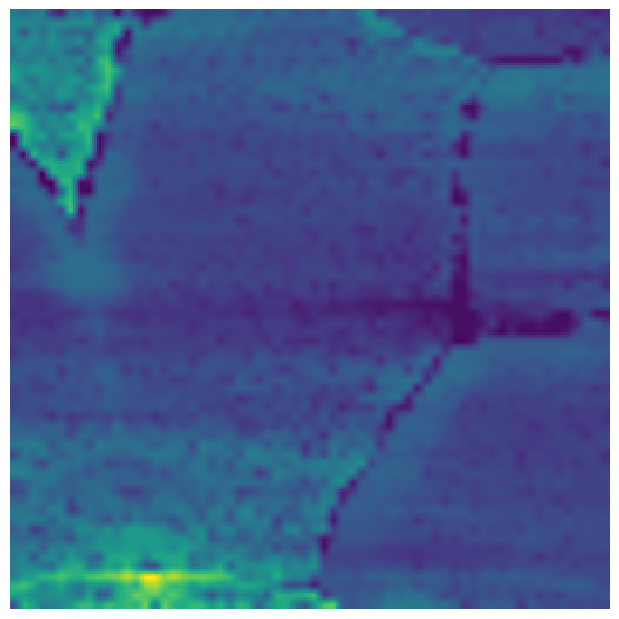

In [ ]:
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
import numpy as np



# image_data = y_hat_bicubic.detach().cpu().squeeze(0)

fig, ax = plt.subplots(figsize=(6, 6), dpi=100)

img = ax.imshow(image_data, cmap='viridis', interpolation='nearest')

ax.axis('off')

pixel_size_um = 2.0 / 512
scalebar = ScaleBar(pixel_size_um, "um",
                    location='lower right',  # position it nicely
                    color='white',
                    box_color='black',
                    box_alpha=0.3,
                    font_properties={'size': 12},
                    length_fraction=0.15,  # custom length relative to axes
                    frameon=True,          # adds a nice box around the scale bar
                    pad=0.4)
ax.add_artist(scalebar)

cbar = plt.colorbar(img, fraction=0.046, pad=0.04)
cbar.set_label('Surface Current (nA)', fontsize=10, labelpad=12)
cbar.ax.tick_params(labelsize=8)

# out_dir = "figures/current-topo-two-row-grid-ii"
plt.tight_layout(pad=0.01)
# plt.savefig(f'{out_dir}/c_bicubic.png', dpi=300, bbox_inches='tight')
plt.show()

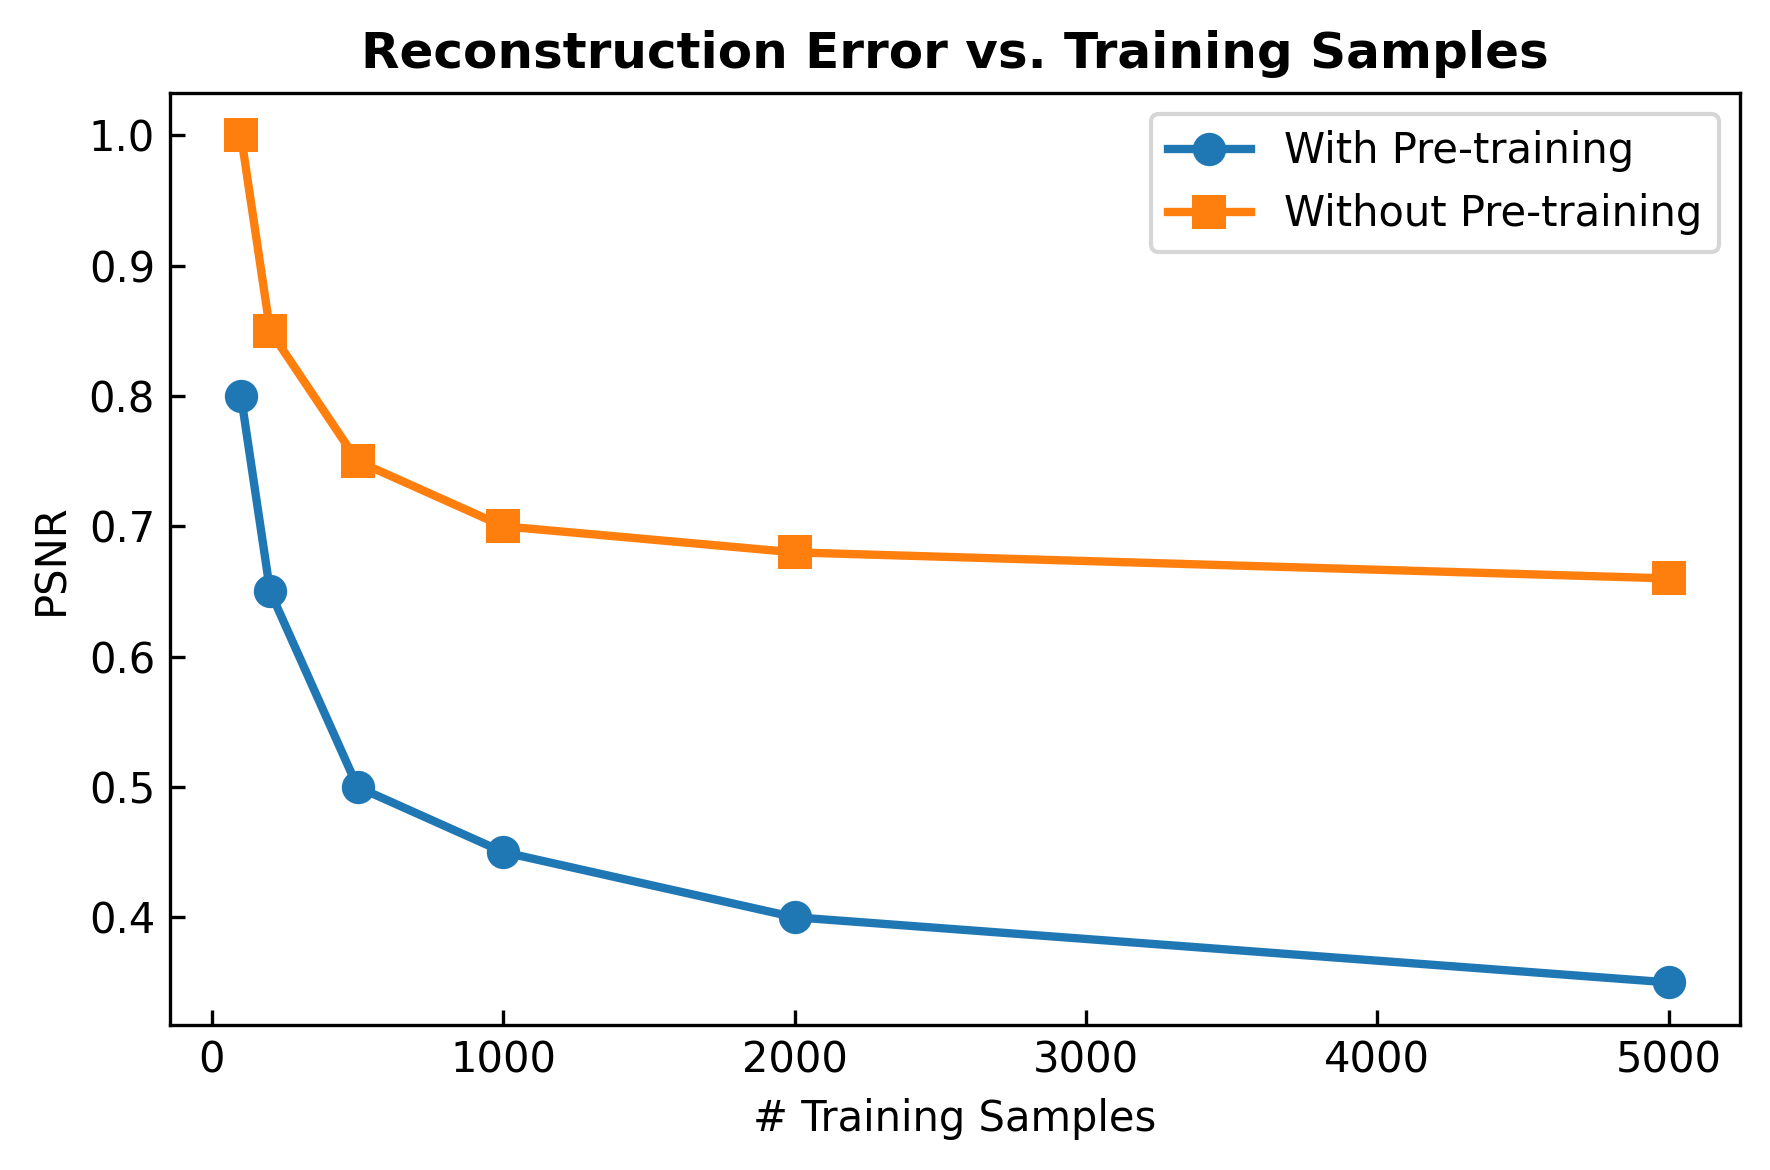

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set seaborn theme (this applies a nice overall aesthetic)
# sns.set_theme("paper")

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# Define the dummy data
training_samples = np.array([100, 200, 500, 1000, 2000, 5000])
error_with_pretraining = np.array([0.80, 0.65, 0.50, 0.45, 0.40, 0.35])
error_without_pretraining = np.array([1.00, 0.85, 0.75, 0.70, 0.68, 0.66])

ax.plot(training_samples, error_with_pretraining,
         marker='o', linestyle='-',
         linewidth=2, markersize=8, 
         markeredgewidth=0,           # Thin border thickness
         label='With Pre-training')

ax.plot(training_samples, error_without_pretraining,
         marker='s', linestyle='-',
         linewidth=2, markersize=8,
         markeredgewidth=0,           # Thin border thickness
         label='Without Pre-training')

# Label the plot and bold the title
ax.set_xlabel('# Training Samples')
ax.set_ylabel('PSNR')
ax.set_title('Reconstruction Error vs. Training Samples', fontweight='bold')
ax.legend()
ax.grid(False)

# Place tick marks inside the axes
ax.tick_params(direction='in')

plt.tight_layout()
plt.show()